In [86]:
from mfld import MeanFieldLangevinDynamics
from generalized_svgd import GeneralizedSVGD
import functions as f
import jax_kernels as ker
from jax import jit, vmap, jacrev

# Data Generation

## Lotka-Volterra model: well-specified

In [2]:
from diffrax import diffeqsolve, ODETerm, Dopri5, SaveAt, Tsit5
import jax.numpy as jnp

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import jax
import numpy as np

import jax.random as jrandom

import time
from functools import partial
#from pcuq_utils import *

cd = jnp.array([0.4, 0.02])
c, d = 0.4, 0.02
def transform(args):
    args = jax.nn.sigmoid(args)
    return jnp.stack([args.at[1].multiply(-1), cd], 0)

def lvfunc(t, y, args):
    u, v = y
    a, b = jax.nn.sigmoid(args)
    du = a * u - b * u * v
    dv = -c * v + d * u * v
    nugget = 1e-6
    return jnp.array([du, dv]) + nugget

#true_param_vals = jnp.array([-2, -4]) + 0.0
true_param_vals = jnp.array([-1, -3]) + 0.0

#x_init = jnp.ones((2,)) * 10.0
x_init = jnp.array([10.0, 15.0])

tmax = 90.0
tobs = 60.0

ts = jnp.linspace(0.0, tobs, 100)

term = ODETerm(lvfunc)
solver = Dopri5()
saveat = SaveAt(ts=ts)

solution = diffeqsolve(term, solver, t0=0, t1=tmax, dt0=0.1, y0=x_init, saveat=SaveAt(dense=True), args=true_param_vals)

## Lotka-Volterra: misspecified

In [3]:
from diffrax import ControlTerm, Euler, MultiTerm, VirtualBrownianTree, ReversibleHeun
key = jrandom.PRNGKey(1) # 15
rng, key = jrandom.split(key)

diff_coef = jnp.array([0.2, 0.2])
diffusion = lambda t, y, args: diff_coef

brownian_motion = VirtualBrownianTree(t0=0, t1=tmax, tol=1e-5, shape=(2,), key=rng)
terms = MultiTerm(ODETerm(lvfunc), ControlTerm(diffusion, brownian_motion))
solver = ReversibleHeun() #Euler()
saveat = SaveAt(dense=True)

sol = diffeqsolve(terms, solver, t0=0, t1=tmax, dt0=0.05, y0=x_init, saveat=saveat, args=true_param_vals)

In [4]:
noise_sigma = 1.0
ts = jnp.linspace(0, tobs, 60)[1:]

obs_1 = jax.vmap(solution.evaluate)(ts)
obs_2 = jax.vmap(sol.evaluate)(ts)

rng, key = jrandom.split(key)
obs_1 += noise_sigma * jrandom.normal(rng, obs_1.shape)
rng, key = jrandom.split(key)
obs_2 += noise_sigma * jrandom.normal(rng, obs_2.shape)

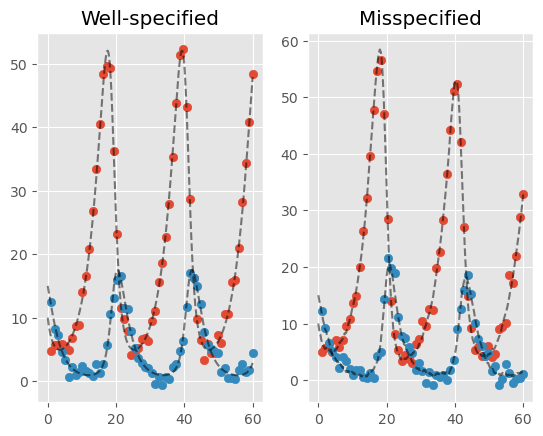

In [5]:
# plot L-V misspecified
# Note: some misspecified solution can be numerically unstable - you might need to choose a random seed that produces trajectories like below


plt.subplot(1, 2, 1)
plt.title("Well-specified")
plt.scatter(ts, obs_1[:, 0])
plt.scatter(ts, obs_1[:, 1])
t1 = jnp.linspace(0, tobs, 1000)
tj = jax.vmap(solution.evaluate)(t1)
plt.plot(t1, tj[:, 0], c='k', linestyle='--', alpha=0.5)
plt.plot(t1, tj[:, 1], c='k', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.title("Misspecified")
plt.scatter(ts, obs_2[:, 0])
plt.scatter(ts, obs_2[:, 1])

tj = jax.vmap(sol.evaluate)(t1)
plt.plot(t1, tj[:, 0], c='k', linestyle='--', alpha=0.5)
plt.plot(t1, tj[:, 1], c='k', linestyle='--', alpha=0.5)
plt.show()

In [6]:
def build_lotka_volterra(y0, ts, params):
    # use parameters to simulate trajectories
    def lvfunc(t, y, args):
        u, v = y
        a, b = jax.nn.sigmoid(args) # transform
        du = a * u - b * u * v
        dv = -c * v + d * u * v
        nugget = 1e-10
        return jnp.array([du, dv]) + nugget
        
    term = ODETerm(lvfunc)
    solver = Tsit5()
    saveat = SaveAt(ts=ts)
    return diffeqsolve(term, solver, t0=ts[0], t1=ts[-1], dt0=0.05, y0=y0, saveat=saveat, args=params).ys

In [71]:
# kernel follows a normal density function
ls2 = 1.0
kernel = lambda x, mu, s2: jnp.exp(jnp.sum(-0.5 * jnp.log(2*jnp.pi*s2) - 0.5 * jnp.square(x-mu)/s2 + 0.5 * jnp.log(2*jnp.pi*ls2)))

def build_first_variation(y0, ts, obs, gamma):
    # this function returns the first variation given the observations (ts, obs), the initial state y0
    def particle_updates_marginalized(params_set, params_set2=None):
        # this function takes a set of particles (params_set) as input, and outputs the first variation of L(Q)
        # the gradient of this function is the drift term for mean-field Langevin diffusion
        n_particles = params_set.shape[0]
        if params_set2 is None:
            params_set2 = params_set.copy()
        params_set2 = jax.lax.stop_gradient(params_set2)
        trajs1 = jax.vmap(build_lotka_volterra, (None, None, 0))(y0, ts, params_set)
        trajs2 = jax.vmap(build_lotka_volterra, (None, None, 0))(y0, ts, params_set2)
            
        s2 = jnp.square(noise_sigma)
            
        def calculate_V(tj):
            kxy = jax.vmap(kernel, (0, 0, None))(obs, tj, s2 + ls2)
            return jnp.sum(kxy)
                
        def calculate_W(tj1, tj2):
            kxy = jax.vmap(kernel, (0, 0, None))(tj2, tj1, 2 * s2 + ls2)
            return jnp.sum(kxy)
                
        Vs = jax.vmap(calculate_V)(trajs1)
        Ws = jax.vmap(jax.vmap(calculate_W, (None, 0)), (0, None))(trajs1, trajs2)
        Ws = jnp.sum(Ws, 1) / n_particles
        #Ws = Ws.at[jnp.diag_indices_from(Ws)].set(0.0)
        #Ws = jnp.sum(Ws, 1) / (n_particles - 1)
            
        return gamma * jnp.sum(Vs - Ws) 
        
    return particle_updates_marginalized

# $\gamma = 10$, $Q_0 = \mathcal{N(0,1)}$

In [102]:
gamma = 10.0
drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_1,gamma)), 0)
gradL = jit(lambda X : -drift_func(X)[1])

c = jnp.array(1.0)
b = 0.5
ell = 0.1
def k(x,y):
    return (c**2 + jnp.sum(jnp.square((x-y) / ell)))**(-b)

def q_0(x):
    d = x.shape[0]
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 * jnp.pi)**d)

def grad_log_q0(x):
    return -x

k = jit(k)
q_0 = jit(q_0)

L = 0

Dictionnary to save the results

In [113]:
results_pcuq = {
    "MFLD contour": {
        "X_fin": None,
        "KGD": None
    },
    "MFLD": {
        "X_fin": None,
        "KGD": None
    },
    "Generalized SVGD": {
        "X_fin": None,
        "KGD_values": None
    },

    "Extensible sampling": {
        "X_fin": None,
        "KGD_values": None}
}

In [115]:
results_pcuq["MFLD contour"]["X_fin"] = results_pcuq_loaded["MFLD contour"]["X_fin"]
results_pcuq["MFLD contour"]["KGD"] = results_pcuq_loaded["MFLD contour"]["KGD"]
results_pcuq["MFLD"]["X_fin"] = results_pcuq_loaded["MFLD"]["X_fin"]
results_pcuq["MFLD"]["KGD"] = results_pcuq_loaded["MFLD"]["KGD"]
results_pcuq["Generalized SVGD"]["X_fin"] = results_pcuq_loaded["Generalized SVGD"]["X_fin"]
results_pcuq["Generalized SVGD"]["KGD_values"] = results_pcuq_loaded["Generalized SVGD"]["KGD_values"]

In [74]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results_pcuq.pkl", "rb") as g:
    results_pcuq = pickle.load(g)

# MFLD for the contour

In [12]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k,gradL=gradL, grad_log_q0=grad_log_q0)

n = 500
T = 30000
eta = 1e-6

params_init = jnp.stack([true_param_vals] * n, 0) - jnp.array([0.5,0.5])
rng, key = jrandom.split(key)
params_init += 1e-4 * jrandom.normal(rng, params_init.shape)
X0 = params_init

key_run = jrandom.PRNGKey(42)
all_particles = MFLD.run_particles(eta,T,X0,key_run,decrease_step_size = None)

In [13]:
X_fin = all_particles[-1]
results_pcuq["MFLD contour"]["X_fin"] = X_fin

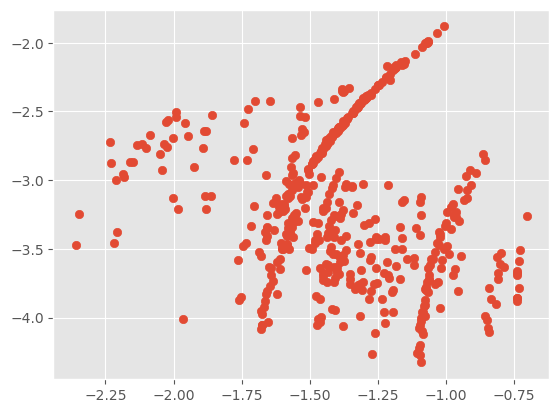

In [14]:
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

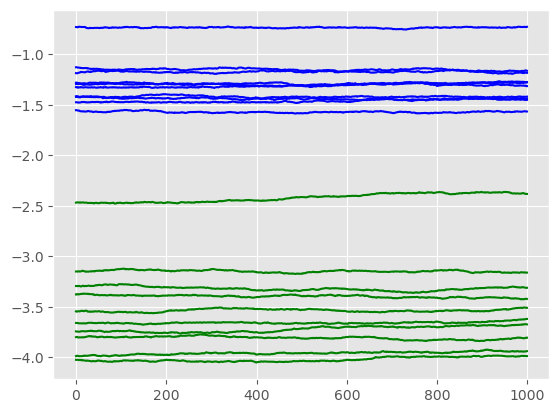

In [15]:
plt.plot(all_particles[-1000:, :10, 0],color = "blue")
plt.plot(all_particles[-1000:, :10, 1],color = "green")
plt.show()

In [16]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["MFLD contour"]["KGD"] = KGD_values

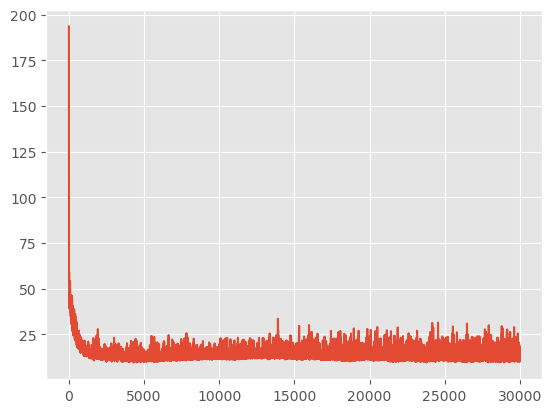

In [59]:
plt.plot(results_pcuq["MFLD contour"]["KGD"][:])
plt.show()

# Mean Field Langevin Dynamic

In [103]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k,gradL=gradL,grad_log_q0=grad_log_q0)

n = 100
T = 5000
eta = 1e-5


params_init = jnp.stack([true_param_vals] * n, 0) - jnp.array([0.5,0.5])
rng, key = jrandom.split(key)
params_init += 1e-3 * jrandom.normal(rng, params_init.shape)
X0 = params_init
key_run = jrandom.PRNGKey(42)
all_particles = MFLD.run_particles(eta,T,X0,key_run,decrease_step_size = None)


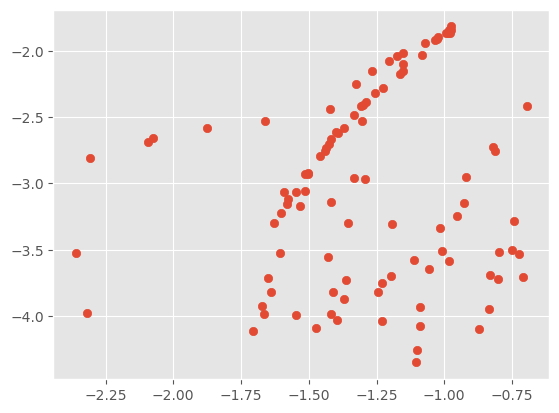

In [104]:
X_fin = all_particles[-1]
results_pcuq["MFLD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

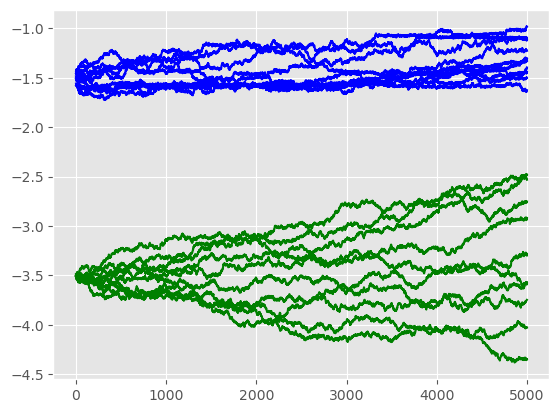

In [105]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [106]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["MFLD"]["KGD"] = KGD_values

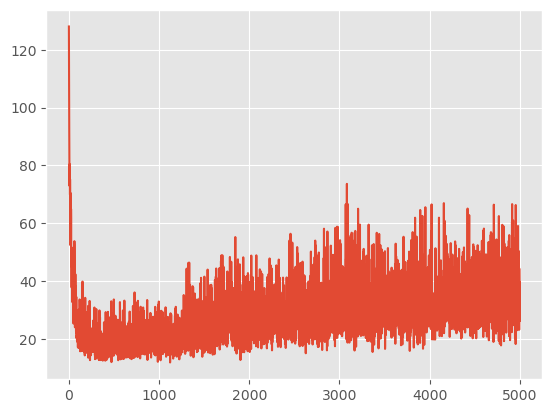

In [107]:
plt.plot(results_pcuq["MFLD"]["KGD"][:])
plt.show()

# Variational Gradient Descent

In [ ]:
# sigma_m = 1.0
# m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
# dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

cm = 1.0
bm = 0.5
ellm = 0.1
def m(x,y):
    return (cm**2 + jnp.sum(jnp.square((x-y) / ellm)))**(-bm)

dmx = jit(jacrev(m ,argnums=0))
M = lambda X,xx : vmap(lambda x: vmap(lambda y: m(x, y))(X))(X)
dMx = lambda X,xx : vmap(lambda x: vmap(lambda y: dmx(x, y))(X))(X)

G_SVGD = GeneralizedSVGD(q_0,L,k,M,dMx,gradL=gradL,grad_log_q0=grad_log_q0)
n = 100
T = 1000
eta = 1e-3

#all_particles_fin = jnp.zeros((len(Sigma_m),n,2))
params_init = jnp.stack([true_param_vals] * n, 0)
rng, key = jrandom.split(key)
params_init += 1e-3 * jrandom.normal(rng, params_init.shape)
X0 = params_init

all_particles = G_SVGD.run_particles(eta,T,X0,decrease_step_size = False)
    # particles_fin = G_SVGD.run_particles(eta,T,X0,decrease_step_size = True)[-1]
    # all_particles_fin = all_particles_fin.at[s].set(particles_fin)

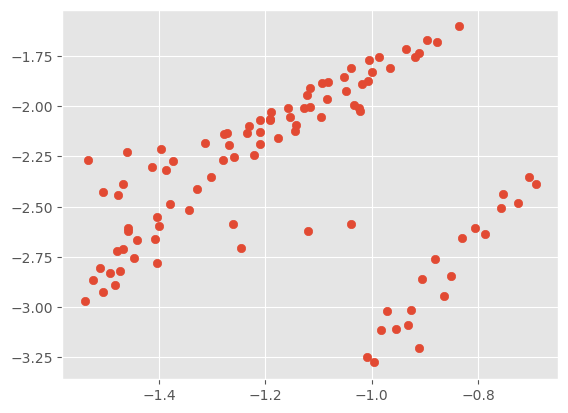

In [98]:
X_fin = all_particles[-1]
results_pcuq["Generalized SVGD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

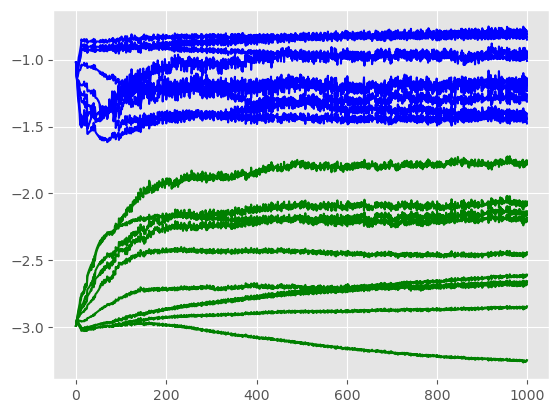

In [99]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [100]:
import functions as f 
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["Generalized SVGD"]["KGD_values"] = KGD_values

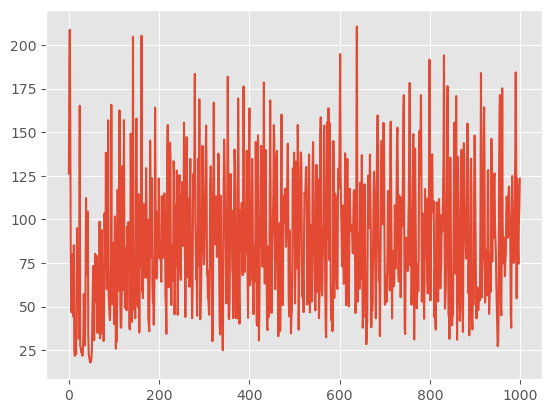

In [101]:
plt.plot(results_pcuq["Generalized SVGD"]["KGD_values"][:])
plt.show()

# Extensible Sampling

In [123]:
from extensible_sampling import ExtensibleSampling
T = 50

ES = ExtensibleSampling(q_0,L,k,gradL=gradL, grad_log_q0=grad_log_q0)

x0 = jnp.array([-1.5,-3.5]) + 0.001 * jrandom.normal(key,shape =2)#params_init

X_fin = ES.run_particles(x0,T,l = -4,u = 0,n0 = 20)
results_pcuq["Extensible Sampling"]["X_fin"] = X_fin

Iteration: 10
Iteration: 20
Iteration: 30
Iteration: 40


KeyError: 'Extensible Sampling'

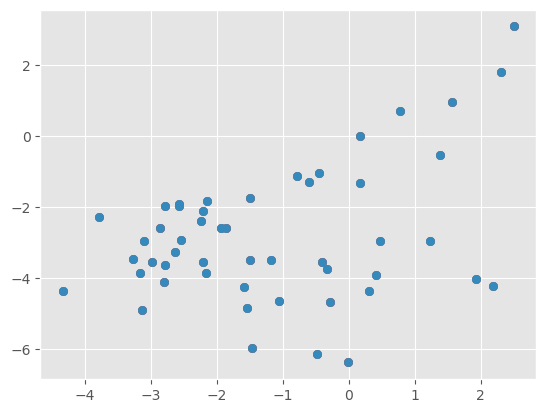

In [126]:
results_pcuq["Extensible sampling"]["X_fin"] = X_fin
plt.scatter(results_pcuq["Extensible sampling"]["X_fin"][:,0], results_pcuq["Extensible sampling"]["X_fin"][:,1])
plt.show()

Save results

In [127]:
import pickle

# Sauvegarde dans un fichier binaire
with open("results_pcuq.pkl", "wb") as gg:
    pickle.dump(results_pcuq, gg)

Load results 

In [128]:
#Upload results
import pickle

# Chargement depuis le fichier
with open("results_pcuq.pkl", "rb") as g:
    results_pcuq_loaded = pickle.load(g)

In [129]:
def kde_mfld(x):
    X = results_pcuq_loaded["MFLD contour"]["X_fin"][:,:2]
    n = X.shape[0]
    h = 1.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

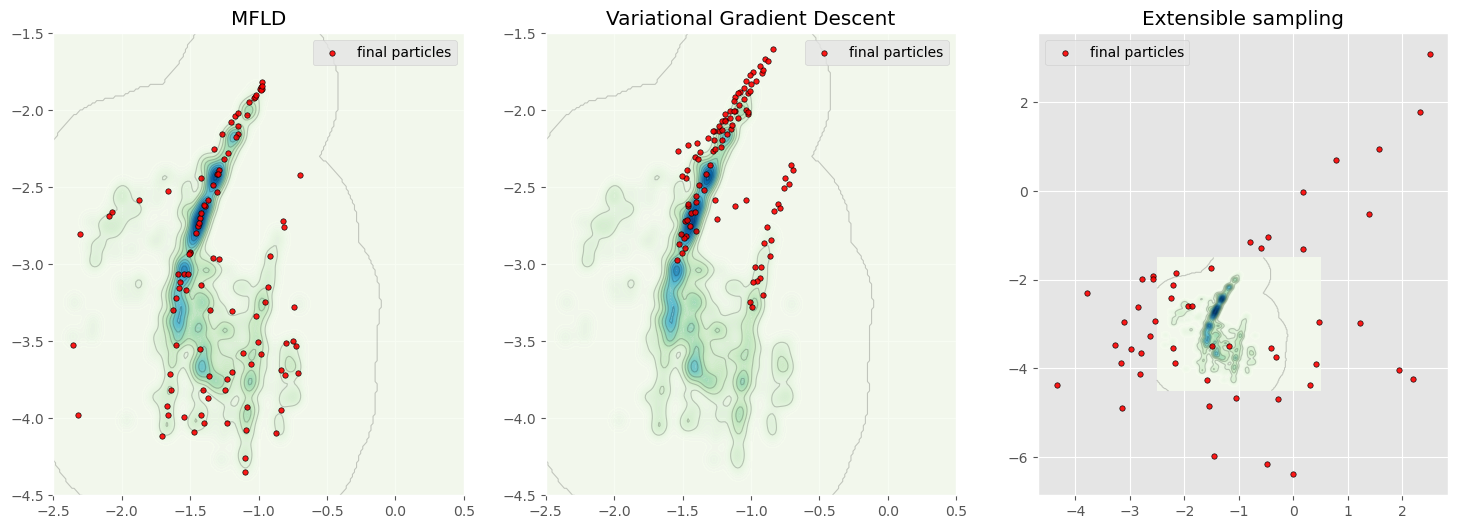

In [131]:
mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-2.5, 0.5, 200)
y = jnp.linspace(-4.5, -1.5, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ind, expe in enumerate(list(results_pcuq_loaded.keys())[1:]):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.8     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results_pcuq_loaded[expe]["X_fin"][:, 0],
        results_pcuq_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    # axes[ind].set_xlim(-5, 4)
    # axes[ind].set_ylim(-5, 4)
    if expe == "Generalized SVGD":
        axes[ind].set_title("Variational Gradient Descent")
    else:
        axes[ind].set_title(expe)
    axes[ind].legend()


plt.show()


# $\gamma = 1$, $Q_0 = \mathcal{N(0,1)}$

In [34]:
gamma = 1.0
drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_1,gamma)), 0)
gradL = jit(lambda X : -drift_func(X)[1])

c = jnp.array(1.0)
b = 1.0
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))**(b)

def q_0(x):
    d = x.shape[0]
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 * jnp.pi)**d)

def grad_log_q0(x):
    return -x

k = jit(k)
q_0 = jit(q_0)

L = 0

In [35]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k,gradL=gradL, grad_log_q0=grad_log_q0)

n = 50
T = 2000
eta = 5e-2

params_init = jnp.stack([true_param_vals] * n, 0) - jnp.array([0.5,0.5])
rng, key = jrandom.split(key)
params_init += 1e-4 * jrandom.normal(rng, params_init.shape)
X0 = params_init
key_run = jrandom.PRNGKey(42)
all_particles = MFLD.run_particles(eta,T,X0,key_run,decrease_step_size = None)

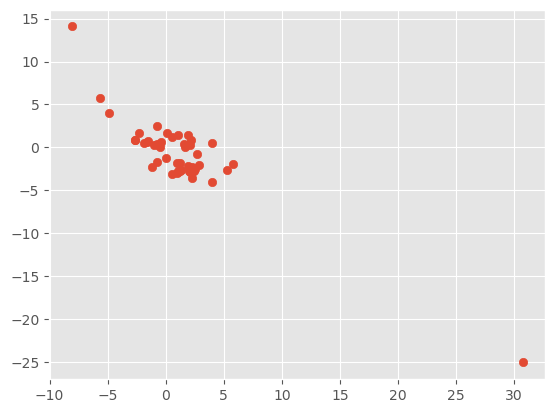

In [36]:
X_fin = all_particles[-1]
results_pcuq["MFLD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

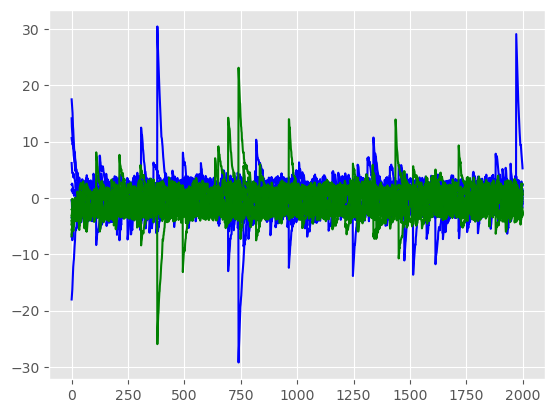

In [37]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [38]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["MFLD"]["KGD"] = KGD_values

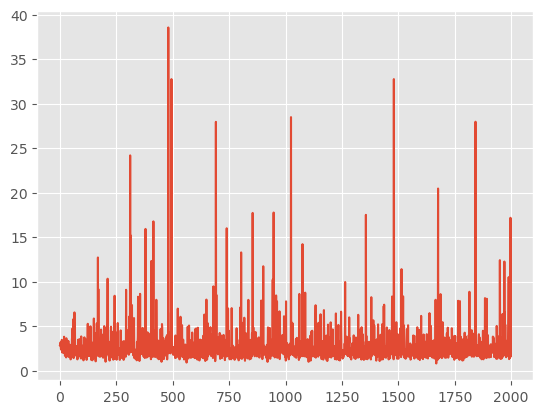

In [39]:
plt.plot(results_pcuq["MFLD"]["KGD"][:])
plt.show()

# Variational gradient descent

In [40]:
sigma_m = 1.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm,gradL=gradL)
n = 50
T = 2000
eta = 1e-2

#all_particles_fin = jnp.zeros((len(Sigma_m),n,2))
params_init = jnp.stack([true_param_vals] * n, 0)
rng, key = jrandom.split(key)
params_init += 1e-1 * jrandom.normal(rng, params_init.shape)
X0 = params_init

all_particles = G_SVGD.run_particles(eta,T,X0,decrease_step_size = False)
    # particles_fin = G_SVGD.run_particles(eta,T,X0,decrease_step_size = True)[-1]
    # all_particles_fin = all_particles_fin.at[s].set(particles_fin)

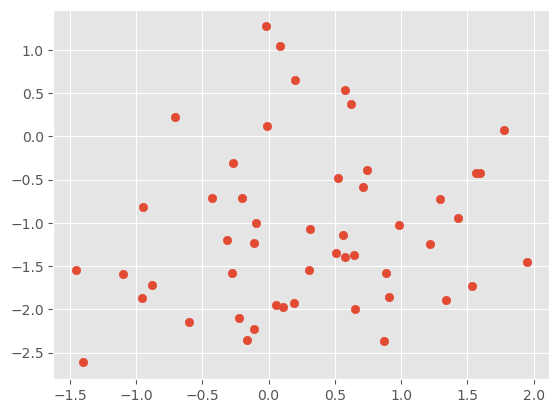

In [41]:
X_fin = all_particles[-1]
results_pcuq["Generalized SVGD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

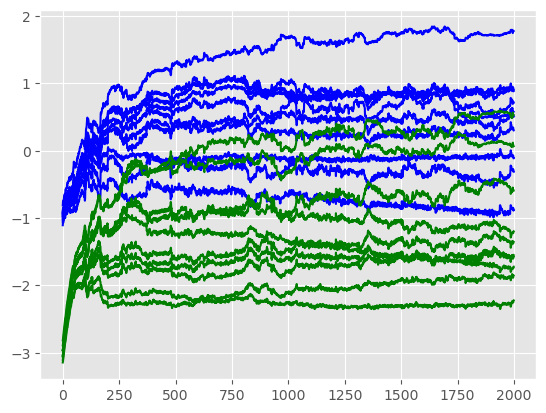

In [42]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [43]:
import functions as f 
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["Generalized SVGD"]["KGD_values"] = KGD_values

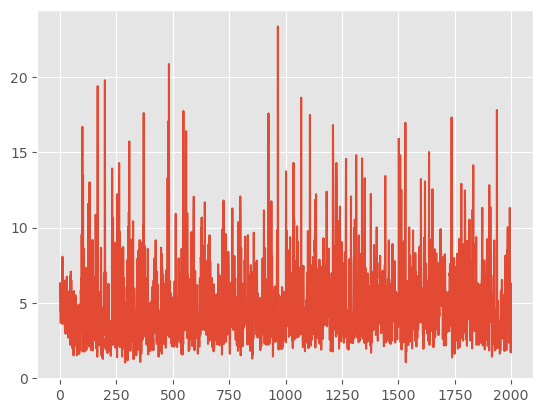

In [44]:
plt.plot(results_pcuq["Generalized SVGD"]["KGD_values"][:])
plt.show()

# $\gamma = 10$, $Q_0 = \mathcal{N}((-3.5,-1.5), I)$, the initialization is centered around $(-3.5,-1.5)$.

In [45]:
gamma = 10.0
drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_1,gamma)), 0)
gradL = jit(lambda X : -drift_func(X)[1])
init = jnp.array([-1.5, -3.5])

c = jnp.array(1.0)
b = 1.0
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))**(b)

def q_0(x):
    d = x.shape[0]
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 * jnp.pi)**d)

def grad_log_q0(x):
    return -(x-init)

k = jit(k)
q_0 = jit(q_0)

L = 0

In [46]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k,gradL=gradL,grad_log_q0=grad_log_q0)

n = 50
T = 5000
eta = 1e-4


#params_init = jnp.stack([true_param_vals] * n, 0) - jnp.array([0.5,0.5])
rng, key = jrandom.split(key)
params_init = init + 1e-4 * jrandom.normal(rng, params_init.shape)
X0 = params_init
key_run = jrandom.PRNGKey(42)
all_particles = MFLD.run_particles(eta,T,X0,key_run,decrease_step_size = 1.0)


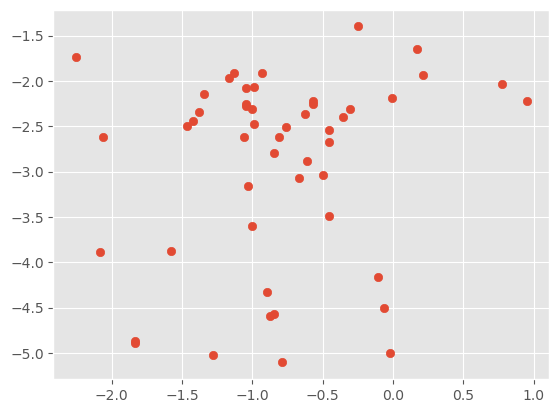

In [47]:
X_fin = all_particles[-1]
results_pcuq["MFLD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

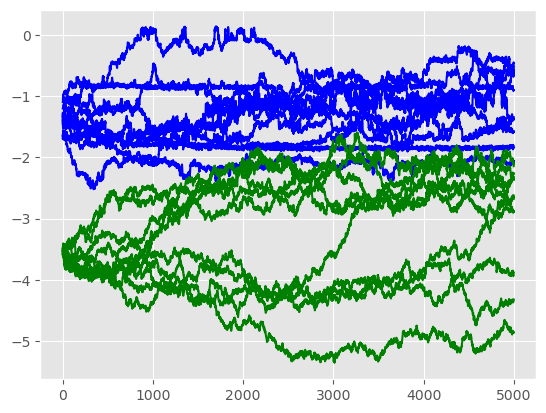

In [48]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [49]:
import functions as f 
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["MFLD"]["KGD_values"] = KGD_values

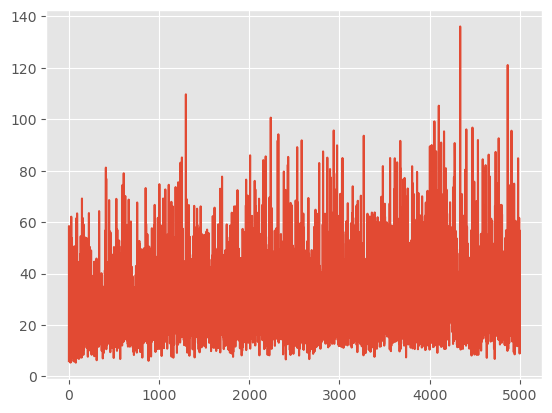

In [50]:
plt.plot(results_pcuq["MFLD"]["KGD_values"][:])
plt.show()

# Variational gradient descent

In [132]:
# sigma_m = 1.0
# m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
# dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

cm = 1.0
bm = 0.5
ellm = 0.1
def m(x,y):
    return (cm**2 + jnp.sum(jnp.square((x-y) / ellm)))**(-bm)

dmx = jit(jacrev(m ,argnums=0))
M = lambda X,xx : vmap(lambda x: vmap(lambda y: m(x, y))(X))(X)
dMx = lambda X,xx : vmap(lambda x: vmap(lambda y: dmx(x, y))(X))(X)

G_SVGD = GeneralizedSVGD(q_0,L,k,M,dMx,gradL=gradL)
n = 100
T = 3000
eta = 1e-3

#all_particles_fin = jnp.zeros((len(Sigma_m),n,2))
#params_init = jnp.stack([true_param_vals] * n, 0)
rng, key = jrandom.split(key)
params_init = init + 1e-1 * jrandom.normal(rng, params_init.shape)
X0 = params_init

all_particles = G_SVGD.run_particles(eta,T,X0,decrease_step_size = False)
    # particles_fin = G_SVGD.run_particles(eta,T,X0,decrease_step_size = True)[-1]
    # all_particles_fin = all_particles_fin.at[s].set(particles_fin)

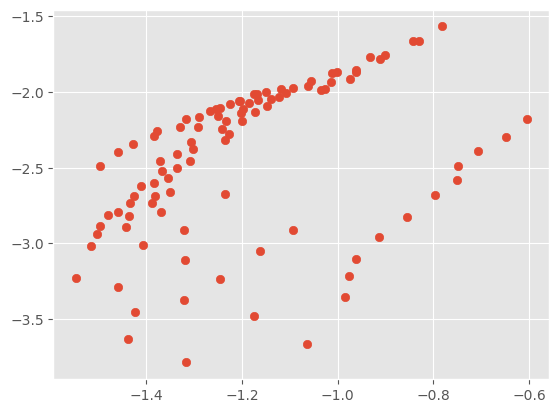

In [133]:
X_fin = all_particles[-1]
results_pcuq["Generalized SVGD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

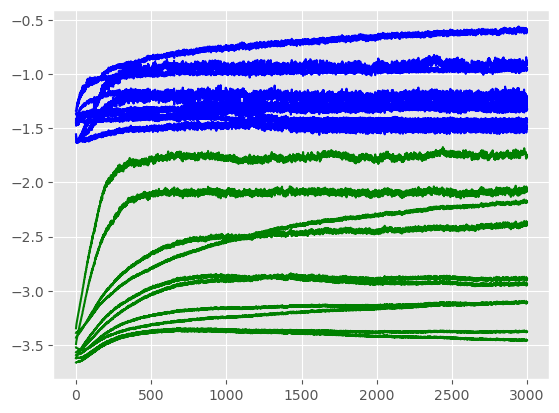

In [134]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [135]:
import functions as f 
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["Generalized SVGD"]["KGD_values"] = KGD_values

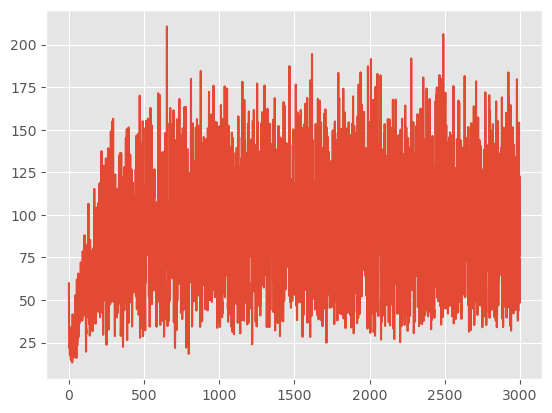

In [136]:
plt.plot(results_pcuq["Generalized SVGD"]["KGD_values"][:])
plt.show()

# $\gamma = 100$, $Q_0 = \mathcal{N}(0,I)$.

In [65]:
gamma = 100.0
drift_func = jax.value_and_grad(jax.jit(build_first_variation(x_init, ts, obs_1,gamma)), 0)
gradL = jit(lambda X : -drift_func(X)[1])
init = jnp.array([-1.5, -3.5])

c = jnp.array(1.0)
b = 1.0
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))**(b)

def q_0(x):
    d = x.shape[0]
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 * jnp.pi)**d)

def grad_log_q0(x):
    return - x

k = jit(k)
q_0 = jit(q_0)

L = 0

In [66]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k,gradL=gradL,grad_log_q0=grad_log_q0)

n = 50
T = 3000
eta = 1e-4


#params_init = jnp.stack([true_param_vals] * n, 0) - jnp.array([0.5,0.5])
rng, key = jrandom.split(key)
params_init = init + 1e-4 * jrandom.normal(rng, params_init.shape)
X0 = params_init
key_run = jrandom.PRNGKey(42)
all_particles = MFLD.run_particles(eta,T,X0,key_run,decrease_step_size = None)

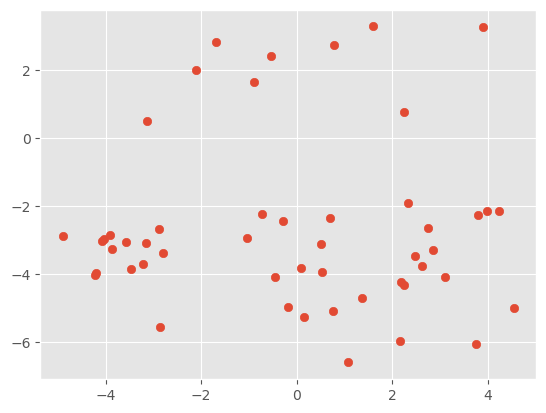

In [67]:
X_fin = all_particles[-1]
results_pcuq["MFLD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

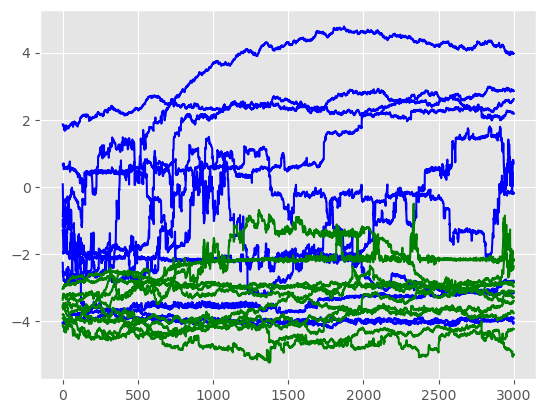

In [68]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [69]:
import functions as f 
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["MFLD"]["KGD_values"] = KGD_values

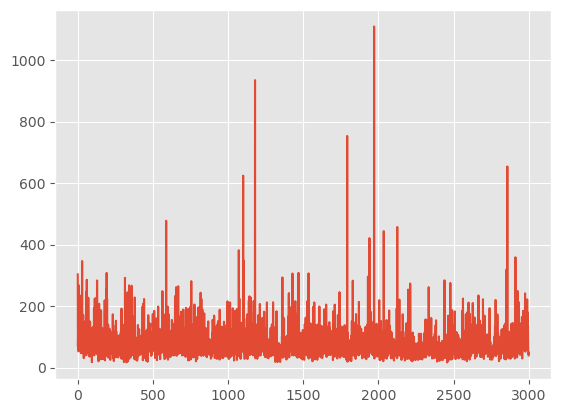

In [70]:
plt.plot(results_pcuq["MFLD"]["KGD_values"][:])
plt.show()

# Variational Gradient Descent

In [58]:
sigma_m = 1.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm,gradL=gradL)
n = 100
T = 5000
eta = 1e-4

#all_particles_fin = jnp.zeros((len(Sigma_m),n,2))
#params_init = jnp.stack([true_param_vals] * n, 0)
rng, key = jrandom.split(key)
params_init = init + 1e-1 * jrandom.normal(rng, params_init.shape)
X0 = params_init

all_particles = G_SVGD.run_particles(eta,T,X0,decrease_step_size = None)
    # particles_fin = G_SVGD.run_particles(eta,T,X0,decrease_step_size = True)[-1]
    # all_particles_fin = all_particles_fin.at[s].set(particles_fin)

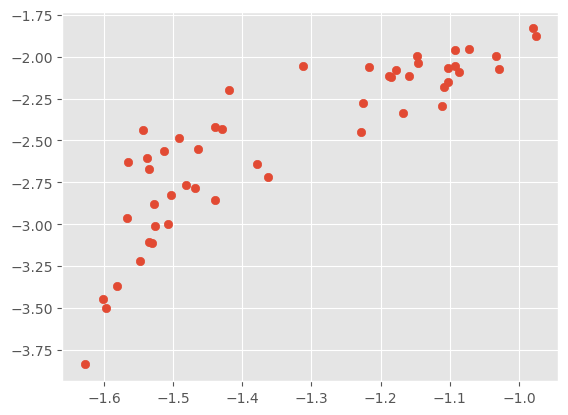

In [61]:
X_fin = all_particles[-1]
results_pcuq["Generalized SVGD"]["X_fin"] = X_fin
plt.scatter(X_fin[:,0], X_fin[:,1])
plt.show()

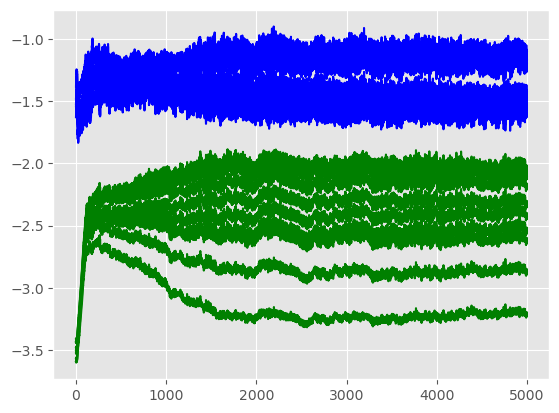

In [62]:
plt.plot(all_particles[:, :10, 0],color = "blue")
plt.plot(all_particles[:, :10, 1],color = "green")
plt.show()

In [63]:
import functions as f 
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(G_SVGD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_values = jnp.zeros(T)

for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))
results_pcuq["Generalized SVGD"]["KGD_values"] = KGD_values

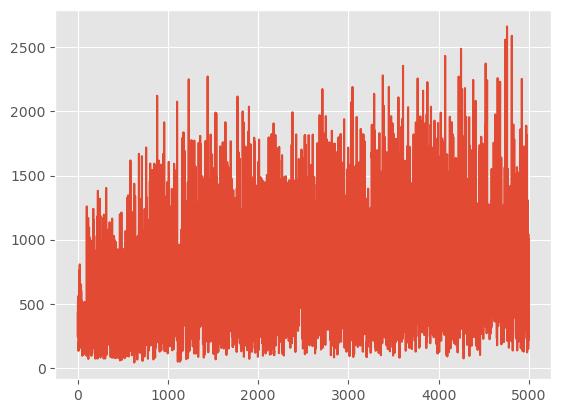

In [64]:
plt.plot(results_pcuq["Generalized SVGD"]["KGD_values"][:])
plt.show()